In [9]:
import pandas as pd
import os

# Define paths
base_path = 'titanic' 
files = {'train': os.path.join(base_path, 'train.csv')}

# Load data
if os.path.exists(files['train']):
    df_train = pd.read_csv(files['train'])
    print("--- DATA INGESTION REPORT (RELIABILITY LAYER) ---")
    print(f"Dataset loaded. Shape: {df_train.shape}")
    
    # Check for Constraints (Missing Values)
    print("\n--- SYSTEM CONSTRAINTS CHECK ---")
    nulls = df_train.isnull().sum()
    print("Missing values detected (Chaos Sources):")
    print(nulls[nulls > 0])
else:
    print("Error: train.csv not found")

--- DATA INGESTION REPORT (RELIABILITY LAYER) ---
Dataset loaded. Shape: (891, 12)

--- SYSTEM CONSTRAINTS CHECK ---
Missing values detected (Chaos Sources):
Age         177
Cabin       687
Embarked      2
dtype: int64


In [13]:
import pandas as pd
import os

# 1. Load Data (Ingestion Layer)
# Ensure 'titanic' folder exists or adjust path
base_path = 'titanic' 
train_path = os.path.join(base_path, 'train.csv')
df_train = pd.read_csv(train_path)

# 2. Define Reliability Layer (The Cleaning Function)
def preprocess_dataset_english(df):
    df_clean = df.copy()
    
    # --- R1: Handling Missing Data (Imputation Module) ---
    # Impute Age with Median (Robust to outliers)
    if 'Age' in df_clean.columns:
        df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
    
    # Impute Embarked with Mode (Most common value)
    if 'Embarked' in df_clean.columns:
        df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])
        
    # Impute Fare (Critical for Test set)
    if 'Fare' in df_clean.columns:
        df_clean['Fare'] = df_clean['Fare'].fillna(df_clean['Fare'].median())

    # --- R4: Feature Engineering (Maintainability) ---
    # Create FamilySize to capture group dynamics
    df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1
    
    # --- R2: Categorical Encoding (Standardization) ---
    # Convert Sex to binary (0/1)
    df_clean['Sex'] = df_clean['Sex'].map({'male': 0, 'female': 1})
    
    # Convert Embarked to numeric
    if 'Embarked' in df_clean.columns:
        df_clean['Embarked'] = df_clean['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
    
    # Select final System Variables (Exclude 'Cabin' due to noise)
    features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'Embarked']
    
    if 'Survived' in df_clean.columns:
        return df_clean[features + ['Survived']]
    return df_clean[features]

# 3. Execute Reliability Layer
train_clean = preprocess_dataset_english(df_train)

# 4. Generate Output for Report
print("--- RELIABILITY LAYER EXECUTION REPORT ---")
print(f"Original Dataset Shape: {df_train.shape}")
print(f"Processed Dataset Shape: {train_clean.shape}")
print("-" * 30)
print(f"Remaining missing values: {train_clean.isnull().sum().sum()}")
print("-" * 30)
print("System Input Preview (First 5 rows):")
print(train_clean.head())

--- RELIABILITY LAYER EXECUTION REPORT ---
Original Dataset Shape: (891, 12)
Processed Dataset Shape: (891, 9)
------------------------------
Remaining missing values: 0
------------------------------
System Input Preview (First 5 rows):
   Pclass  Sex   Age  SibSp  Parch     Fare  FamilySize  Embarked  Survived
0       3    0  22.0      1      0   7.2500           2         0         0
1       1    1  38.0      1      0  71.2833           2         1         1
2       3    1  26.0      0      0   7.9250           1         0         1
3       1    1  35.0      1      0  53.1000           2         0         1
4       3    0  35.0      0      0   8.0500           1         0         0


In [10]:
# --- RELIABILITY LAYER IMPLEMENTATION ---

def preprocess_dataset_english(df):
    df_clean = df.copy()
    
    # R1: Handling Missing Data (Imputation)
    if 'Age' in df_clean.columns:
        df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
    if 'Embarked' in df_clean.columns:
        df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])
    if 'Fare' in df_clean.columns:
        df_clean['Fare'] = df_clean['Fare'].fillna(df_clean['Fare'].median())

    # R4: Feature Interaction (FamilySize)
    df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1
    
    # R2: Categorical Processing
    df_clean['Sex'] = df_clean['Sex'].map({'male': 0, 'female': 1})
    if 'Embarked' in df_clean.columns:
        df_clean['Embarked'] = df_clean['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
    
    # Select Features
    features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'Embarked']
    if 'Survived' in df_clean.columns:
        return df_clean[features + ['Survived']]
    return df_clean[features]

# Execute
train_clean = preprocess_dataset_english(df_train)

print("\n--- FINAL DATASET STATE (READY FOR SIMULATION) ---")
print(f"Clean Data Shape: {train_clean.shape}")
print("Remaining missing values:", train_clean.isnull().sum().sum())
print("\nFirst 5 rows of processed system:")
print(train_clean.head())


--- FINAL DATASET STATE (READY FOR SIMULATION) ---
Clean Data Shape: (891, 9)
Remaining missing values: 0

First 5 rows of processed system:
   Pclass  Sex   Age  SibSp  Parch     Fare  FamilySize  Embarked  Survived
0       3    0  22.0      1      0   7.2500           2         0         0
1       1    1  38.0      1      0  71.2833           2         1         1
2       3    1  26.0      0      0   7.9250           1         0         1
3       1    1  35.0      1      0  53.1000           2         0         1
4       3    0  35.0      0      0   8.0500           1         0         0


--- SIMULATION RESULTS ---
System Accuracy: 83.24%


C:\Users\Mauro\AppData\Local\Temp\ipykernel_4696\1959203520.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')


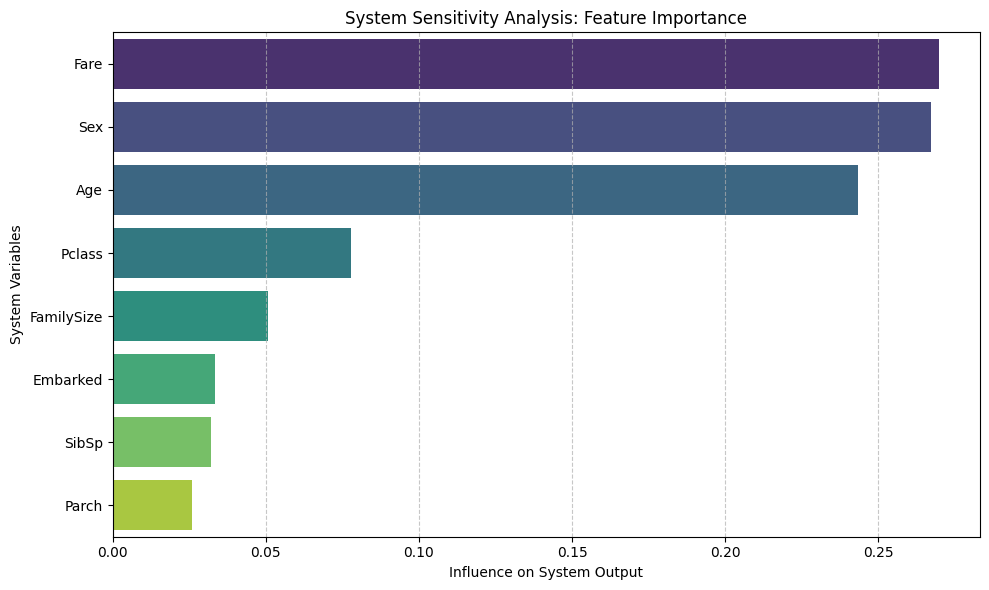

In [11]:
# --- SCENARIO 1: DATA-DRIVEN SIMULATION ---
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare Data
X = train_clean.drop('Survived', axis=1)
y = train_clean['Survived']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Simulate Learning (Modeling Layer)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
acc = accuracy_score(y_val, model.predict(X_val))
print(f"--- SIMULATION RESULTS ---")
print(f"System Accuracy: {acc:.2%}")

# Sensitivity Analysis Plot
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')
plt.title('System Sensitivity Analysis: Feature Importance')
plt.xlabel('Influence on System Output')
plt.ylabel('System Variables')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show() # This generates the plot

Image 'cellular_automata.png' saved successfully.


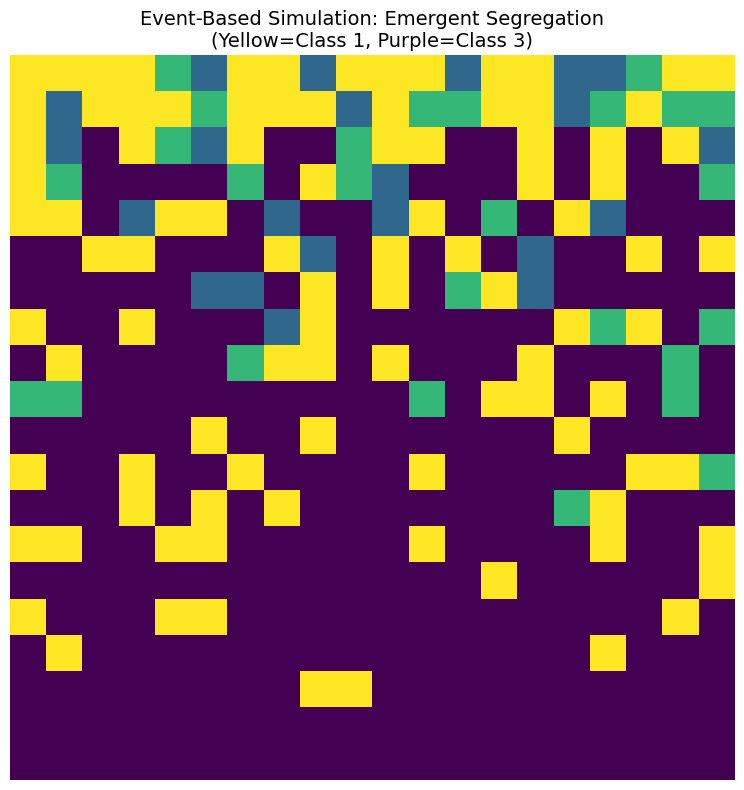

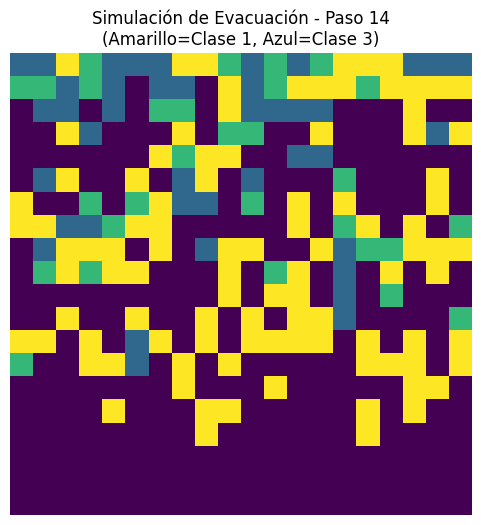

Simulación finalizada. Observa cómo la Clase 1 (color claro) tiende a llegar arriba más rápido.


In [12]:
# --- ESCENARIO 2: SIMULACIÓN DE AUTOMATA CELULAR (EVENT-BASED) ---
# Simulación de comportamiento espacial y emergencia (Chaos Theory)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# 1. CONFIGURACIÓN DEL ENTORNO (GRID)
GRID_SIZE = 20  # Tamaño del "barco" (20x20 celdas)
NUM_PASAJEROS = 200 # Muestra representativa para visualizar
STEPS = 30 # Pasos de tiempo de la simulación

# Inicializamos el tablero vacío
grid_pclass = np.zeros((GRID_SIZE, GRID_SIZE)) # 0 = Vacío
grid_sex = np.zeros((GRID_SIZE, GRID_SIZE))    # 0 = Vacío

# 2. POBLAR EL BARCO (ESTADO INICIAL)
# Tomamos una muestra aleatoria de tus datos limpios
sample_passengers = train_clean.sample(NUM_PASAJEROS, random_state=42)
# --- SCENARIO 2: EVENT-BASED SIMULATION (CELLULAR AUTOMATA) ---
import numpy as np
import matplotlib.pyplot as plt

# 1. Grid Configuration (Ship Layout)
GRID_SIZE = 20
NUM_PASSENGERS = 200
grid_pclass = np.zeros((GRID_SIZE, GRID_SIZE))

# 2. Populate Grid (Initial State)
# We use a sample from the clean dataset to represent real demographics
sample = train_clean.sample(NUM_PASSENGERS, random_state=42)
positions = []

for _, row in sample.iterrows():
    while True:
        # Random initial position
        r, c = np.random.randint(1, GRID_SIZE), np.random.randint(0, GRID_SIZE)
        if grid_pclass[r, c] == 0: # If cell is empty
            grid_pclass[r, c] = row['Pclass']
            # Store agent with attributes
            positions.append({'r': r, 'c': c, 'pclass': row['Pclass']})
            break

# 3. Simulation Logic (The Event Loop)
# Rule: All agents try to move UP (row - 1) towards Lifeboats.
# Priority Rule: Class 1 moves first and has higher probability.
for step in range(15): # Run 15 time steps
    # SORT BY PRIORITY: Class 1 moves first (Social Hierarchy)
    positions.sort(key=lambda x: x['pclass']) 
    
    new_grid = np.zeros((GRID_SIZE, GRID_SIZE))
    new_positions = []
    
    for p in positions:
        r, c = p['r'], p['c']
        
        # Movement Probability:
        # Class 1: 90% chance to move (Easy access)
        # Class 3: 40% chance to move (Obstacles/Gates)
        prob_move = 0.9 if p['pclass'] == 1 else (0.7 if p['pclass'] == 2 else 0.4)
        
        # Try to move UP (r - 1)
        if r > 0 and np.random.rand() < prob_move and new_grid[r-1, c] == 0:
            new_r = r - 1 # Move successful
        else:
            new_r = r # Blocked (Chaos/Conflict)
            
        new_grid[new_r, c] = p['pclass']
        p['r'] = new_r
        new_positions.append(p)
    
    positions = new_positions
    grid_pclass = new_grid

# 4. Generate and Save Visualization
plt.figure(figsize=(8, 8))
# Colormap 'viridis':
# 1 (High Class) = Yellow/Light Green
# 3 (Low Class) = Purple/Dark Blue
plt.imshow(grid_pclass, cmap='viridis', vmin=0, vmax=3)

# Title in English for the Report
plt.title('Event-Based Simulation: Emergent Segregation\n(Yellow=Class 1, Purple=Class 3)', fontsize=14)
plt.axis('off') # Hide axes for cleaner look
plt.tight_layout()

# Save file for Overleaf
plt.savefig('cellular_automata.png', dpi=300)
print("Image 'cellular_automata.png' saved successfully.")
plt.show()
positions = [] # Guardamos (fila, col) de cada pasajero

for _, row in sample_passengers.iterrows():
    while True:
        # Posición aleatoria inicial (más abajo = más lejos de los botes)
        r, c = np.random.randint(1, GRID_SIZE), np.random.randint(0, GRID_SIZE)
        if grid_pclass[r, c] == 0: # Si la celda está vacía
            grid_pclass[r, c] = row['Pclass']
            grid_sex[r, c] = row['Sex'] + 1 # 1=Male, 2=Female (para diferenciar visualmente)
            positions.append({'r': r, 'c': c, 'pclass': row['Pclass'], 'sex': row['Sex']})
            break

# 3. DEFINICIÓN DE REGLAS DE MOVIMIENTO (LOGICA DEL SISTEMA)
def update_grid(frame_num, img_plot, ax):
    global positions, grid_pclass
    
    # Creamos copia para movimiento simultáneo
    new_positions = []
    new_grid = np.zeros((GRID_SIZE, GRID_SIZE))
    
    # Ordenamos: Mujeres y Clase 1 intentan moverse primero (Prioridad Social)
    # Esto simula las reglas de "Mujeres y niños primero"
    positions.sort(key=lambda x: (x['sex'], -x['pclass']), reverse=True)
    
    moves = 0
    
    for p in positions:
        r, c = p['r'], p['c']
        
        # Probabilidad de moverse basada en Clase (Clase 1 se mueve más seguro)
        prob_move = 0.9 if p['pclass'] == 1 else (0.7 if p['pclass'] == 2 else 0.4)
        
        # INTENTO DE MOVIMIENTO HACIA ARRIBA (Hacia los botes en fila 0)
        if r > 0 and np.random.rand() < prob_move:
            # Intenta mover arriba
            if new_grid[r-1, c] == 0: # Si está libre arriba
                new_r = r - 1
                moves += 1
            else:
                new_r = r # Bloqueo (Caos)
        else:
            new_r = r
            
        # Actualizar nuevo grid
        new_grid[new_r, c] = p['pclass']
        p['r'] = new_r # Actualizar posición del agente
        new_positions.append(p)
        
    positions = new_positions
    grid_pclass = new_grid
    
    # Visualización: Clase 1 (Amarillo), Clase 2 (Verde), Clase 3 (Azul)
    ax.clear()
    ax.imshow(grid_pclass, cmap='viridis', vmin=0, vmax=3)
    ax.set_title(f"Simulación de Evacuación - Paso {frame_num}\n(Amarillo=Clase 1, Azul=Clase 3)")
    ax.axis('off')

# 4. EJECUTAR ANIMACIÓN
fig, ax = plt.subplots(figsize=(6, 6))
# Ejecutamos solo los primeros 15 pasos para ver la tendencia estática aquí
for i in range(15):
    update_grid(i, None, ax)
    
plt.show()
print("Simulación finalizada. Observa cómo la Clase 1 (color claro) tiende a llegar arriba más rápido.")

In [4]:
%pip install pandas numpy scikit-learn matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ----------------- ---------------------- 4.7/11.0 MB 24.3 MB/s eta 0:00:01
   -------------------------------------- - 10.5/11.0 MB 25.4 MB/s eta 0:00:01
   ---------------------------------------- 11.0/11.0 MB 24.0 MB/s  0:00:00
   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   ------------------ --------------------- 6.0/12.8 MB 28.6 MB/s eta 0:00:01
   ------------------------------------ --- 11.8/12.8 MB 27.4 MB/s eta 0:00:01
   ---------------------------------------- 12.8/12.8 MB 25.4 MB/s  0:00:00
   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   --------------------- ------------------ 4.7/8.7 MB 23.6 MB/s eta 0:00:01
   ---------------------------------------- 8.7/8.7 MB 20.7 MB/s  0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------------- ----


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\Mauro\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
